In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

In [2]:
results_heishiro = {
    "MFLD contour": {
        "X_fin": None,
        "KGD_values": None
    },
    "MFLD": {
        "X_fin": None,
        "KGD_values": None
    },
    "KGD Descent": {
        "X_fin": None,
        "KGD_values": None
    },
    "Variational Inference": {
        "X_fin": None,
        "KGD_values": None
    }
}

In [3]:
import pickle

with open("results_heishiro.pkl", "rb") as g:
    results_heishiro_loaded = pickle.load(g)

In [4]:
def kde_mfld(x):
    X = results_heishiro_loaded["MFLD contour"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 10.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

Text(0.5, 1.0, 'KGD')

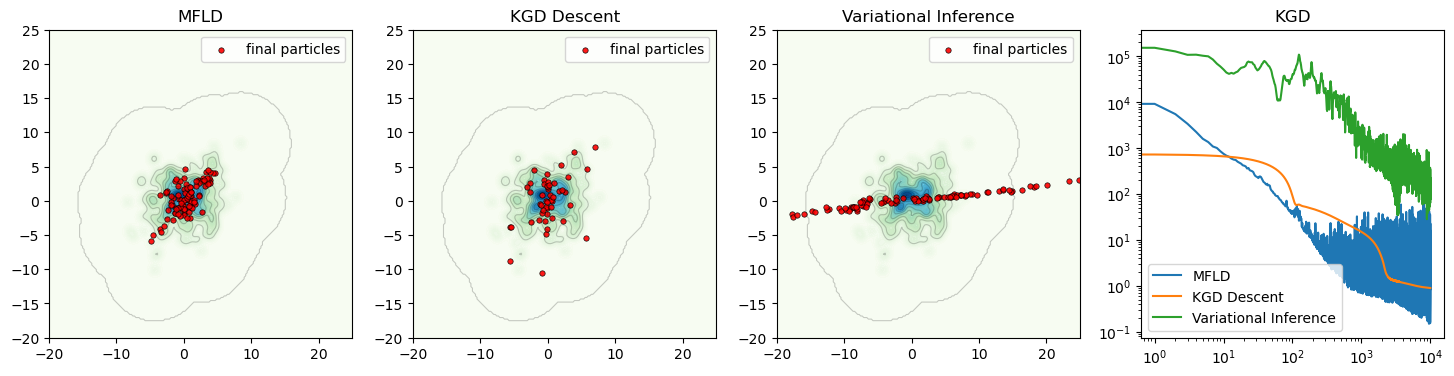

In [16]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-20, 25, 200)
y = jnp.linspace(-20, 25, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ind, expe in enumerate(list(results_heishiro_loaded.keys())[1:]):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.8     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_heishiro_loaded[expe]["X_fin"][:, 0],
        results_heishiro_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    # axes[ind].set_xlim(-5, 5)
    # axes[ind].set_ylim(-5, 5)
    
    axes[ind].set_title(expe)
    axes[ind].legend()
axes[3].plot(results_heishiro_loaded["MFLD"]["KGD_values"],label="MFLD")
axes[3].plot(results_heishiro_loaded["KGD Descent"]["KGD_values"],label="KGD Descent")
axes[3].plot(results_heishiro_loaded["Variational Inference"]["KGD_values"],label="Variational Inference")
axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_title("KGD")

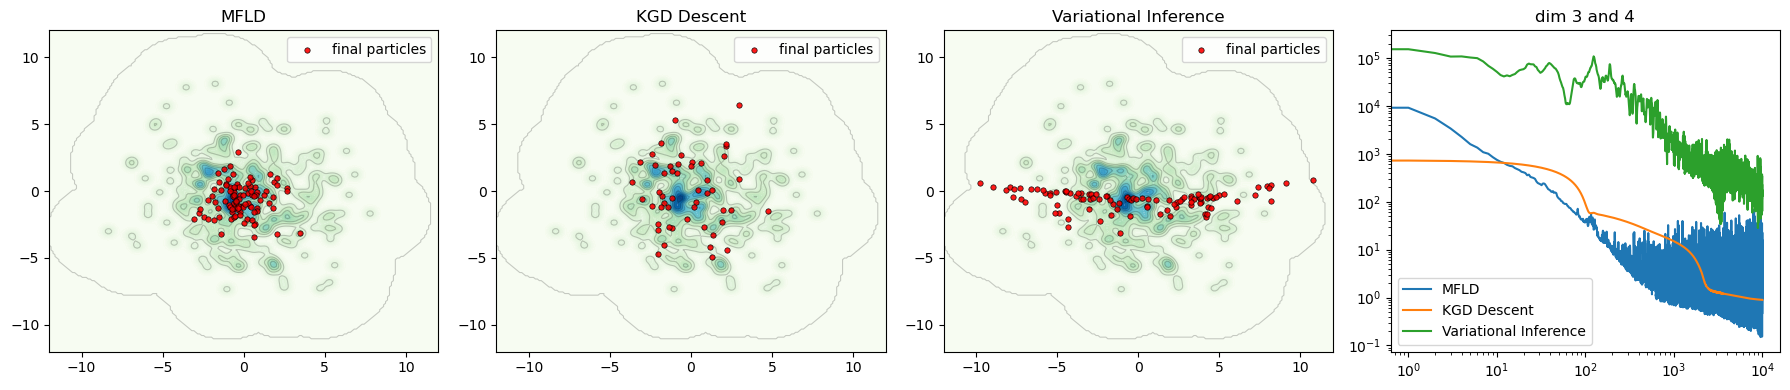

In [17]:
def kde_mfld_dim34(x):
    X = results_heishiro_loaded["MFLD contour"]["X_fin"][:,2:]
    n = X.shape[0]
    h = 5.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-12, 12, 200)
y = jnp.linspace(-12, 12, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld_dim34(jnp.array([x, y])) for x in x] for y in y])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ind, expe in enumerate(list(results_heishiro_loaded.keys())[1:]):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.8     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_heishiro_loaded[expe]["X_fin"][:, 2],
        results_heishiro_loaded[expe]["X_fin"][:, 3],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    # axes[ind].set_xlim(-5, 5)
    # axes[ind].set_ylim(-5, 5)
    if expe == "VI":
        axes[ind].set_title("KGD descent")
    else:
        axes[ind].set_title(expe)
    axes[ind].legend()

axes[3].plot(results_heishiro_loaded["MFLD"]["KGD_values"],label="MFLD")
axes[3].plot(results_heishiro_loaded["KGD Descent"]["KGD_values"],label="KGD Descent")
axes[3].plot(results_heishiro_loaded["Variational Inference"]["KGD_values"],label="Variational Inference")
axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_title("KGD")


plt.title("dim 3 and 4")
plt.tight_layout()
plt.show()